# Synthetic Light-Curve Missing Data Imputation Analysis

This notebook implements the synthetic-data experiment described in the thesis:

- Generate a periodic astronomical light curve with Gaussian noise
- Inject MCAR missingness (10%, 30%, 50%) using scattered + block gaps
- Apply imputation methods
- Evaluate reconstruction fidelity:
  - RMSE
  - MAE
  - Lomb–Scargle period recovery
  - amplitude preservation
  - phase preservation
  - computational cost

The benchmark follows the thesis design: a known ground-truth synthetic signal is used so reconstruction error can be measured exactly.

In [1]:
# Install dependencies if required
# !pip install numpy pandas scipy scikit-learn matplotlib seaborn tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d, CubicSpline
from scipy.signal import lombscargle
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

import time
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


## 1. Synthetic periodic light-curve generation

Signal model:

f(t) = μ + A sin(2πt/P + φ) + ε

where ε is additive Gaussian noise.

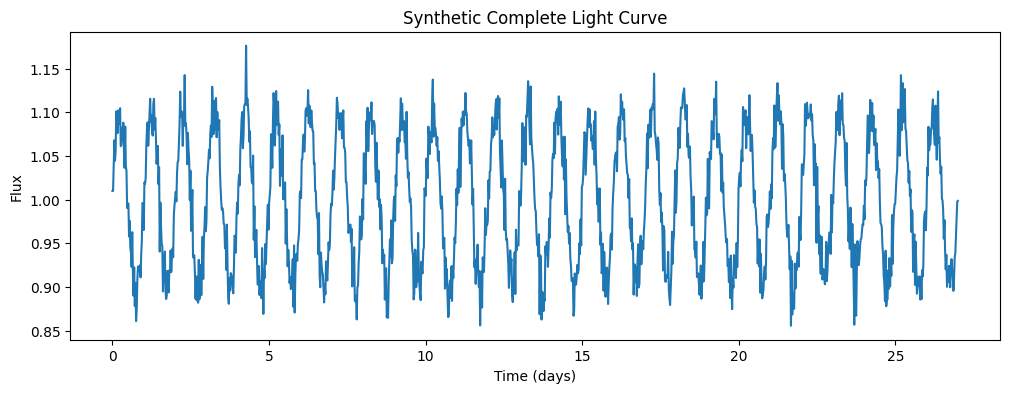

In [2]:
def generate_lightcurve(
    N=1323,
    duration=27,
    amplitude=0.1,
    period=1.0,
    phase=0,
    noise_std=0.02
):
    t = np.linspace(0, duration, N)
    signal = amplitude*np.sin(2*np.pi*t/period + phase)
    noise = np.random.normal(0, noise_std, N)
    flux = 1 + signal + noise
    return t, flux

t, true_flux = generate_lightcurve()

plt.figure(figsize=(12,4))
plt.plot(t, true_flux)
plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.title("Synthetic Complete Light Curve")
plt.show()


## 2. MCAR gap injection

Missing fractions:
- 10%
- 30%
- 50%

A mixture of random scattered points and contiguous blocks is used.

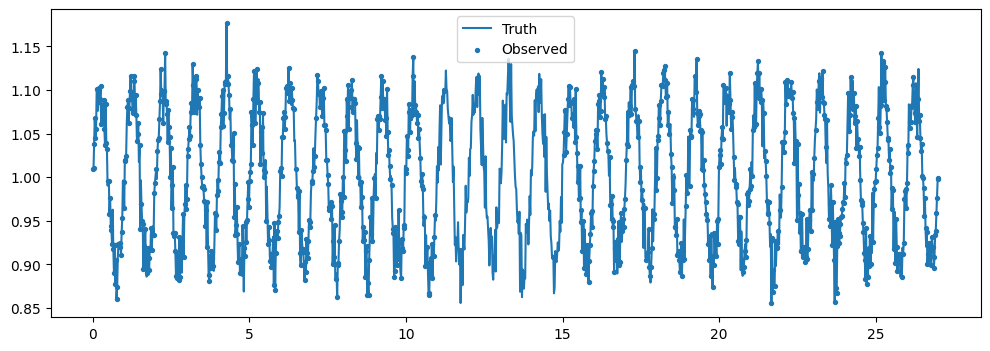

In [3]:
def inject_gaps(y, missing_fraction=0.3, seed=1):
    rng = np.random.default_rng(seed)
    n = len(y)
    mask = np.ones(n, dtype=bool)

    n_missing = int(n*missing_fraction)

    scattered = rng.choice(n, size=int(0.5*n_missing), replace=False)
    mask[scattered] = False

    remaining = n_missing - len(scattered)
    start = rng.integers(0, n-remaining)
    mask[start:start+remaining] = False

    observed = y.copy()
    observed[~mask] = np.nan
    return observed, mask

observed_flux, mask = inject_gaps(true_flux, 0.3)

plt.figure(figsize=(12,4))
plt.plot(t,true_flux,label="Truth")
plt.scatter(t[mask],observed_flux[mask],s=8,label="Observed")
plt.legend()
plt.show()


## 3. Imputation methods

In [4]:
def mean_fill(y):
    out=y.copy()
    out[np.isnan(out)] = np.nanmean(y)
    return out

def forward_fill(y):
    return pd.Series(y).ffill().bfill().values

def linear_interp(t,y):
    out=y.copy()
    idx=np.isfinite(y)
    f=interp1d(t[idx],y[idx],fill_value="extrapolate")
    out[~idx]=f(t[~idx])
    return out

def spline_interp(t,y):
    out=y.copy()
    idx=np.isfinite(y)
    f=CubicSpline(t[idx],y[idx])
    out[~idx]=f(t[~idx])
    return out

def knn_impute(t,y,k=5):
    out=y.copy()
    idx=np.isfinite(y)
    X=t[idx].reshape(-1,1)
    model=KNeighborsRegressor(k)
    model.fit(X,y[idx])
    out[~idx]=model.predict(t[~idx].reshape(-1,1))
    return out

def rf_impute(t,y):
    out=y.copy()
    idx=np.isfinite(y)
    model=RandomForestRegressor(
        n_estimators=100,
        random_state=0
    )
    model.fit(t[idx].reshape(-1,1),y[idx])
    out[~idx]=model.predict(t[~idx].reshape(-1,1))
    return out


methods = {
    "Mean": mean_fill,
    "Forward Fill": forward_fill,
    "Linear": lambda y: linear_interp(t,y),
    "Spline": lambda y: spline_interp(t,y),
    "KNN": lambda y: knn_impute(t,y),
    "Random Forest": lambda y: rf_impute(t,y)
}


## 4. Evaluation metrics

In [5]:
def period_estimate(time, flux):
    freq = np.linspace(0.1,10,5000)
    power = lombscargle(time, flux-np.mean(flux), freq)
    best=freq[np.argmax(power)]
    return 1/best


def evaluate(true, reconstructed, t):
    missing=np.isnan(observed_flux)
    rmse=np.sqrt(np.mean((true[missing]-reconstructed[missing])**2))
    mae=np.mean(np.abs(true[missing]-reconstructed[missing]))

    p=period_estimate(t,reconstructed)
    amp=(np.max(reconstructed)-np.min(reconstructed))/2

    return {
        "RMSE":rmse,
        "MAE":mae,
        "Period":p,
        "Amplitude":amp
    }


## 5. Run benchmark over missingness levels and seeds

In [6]:
results=[]

for frac in [0.1,0.3,0.5]:
    for seed in range(30):
        observed_flux, mask = inject_gaps(true_flux, frac, seed)

        for name, method in methods.items():
            start=time.time()

            if name in ["Mean","Forward Fill"]:
                rec=method(observed_flux)
            else:
                rec=method(observed_flux)

            runtime=time.time()-start

            row=evaluate(true_flux,rec,t)
            row.update({
                "Method":name,
                "Missingness":frac,
                "Seed":seed,
                "Runtime":runtime
            })
            results.append(row)

results=pd.DataFrame(results)
results.head()


,RMSE,MAE,Period,Amplitude,Method,Missingness,Seed,Runtime
0,0.074153,0.065545,0.159115,0.160404,Mean,0.1,0,0.000559
1,0.084498,0.058503,0.159165,0.160404,Forward Fill,0.1,0,0.014528
2,0.068721,0.050581,0.159115,0.160404,Linear,0.1,0,0.000893
3,0.283124,0.175325,0.159165,0.360450,Spline,0.1,0,0.010448
4,0.091371,0.065485,0.159165,0.160404,KNN,0.1,0,0.009928


## 6. Summary tables and visualisation

In [7]:
summary = results.groupby(
    ["Method","Missingness"]
).agg(
    RMSE=("RMSE","mean"),
    MAE=("MAE","mean"),
    Runtime=("Runtime","mean")
).reset_index()

summary


,Method,Missingness,RMSE,MAE,Runtime
0,Forward Fill,0.1,0.073891,0.053048,0.001099
1,Forward Fill,0.3,0.075833,0.055779,0.000567
2,Forward Fill,0.5,0.073445,0.055534,0.000648
3,KNN,0.1,0.086305,0.061723,0.003255
4,KNN,0.3,0.074146,0.051841,0.003459
5,KNN,0.5,0.077371,0.055230,0.003837
6,Linear,0.1,0.064667,0.047558,0.000505
7,Linear,0.3,0.074519,0.053222,0.000382
8,Linear,0.5,0.072584,0.052745,0.000403
9,Mean,0.1,0.073310,0.064693,0.000149


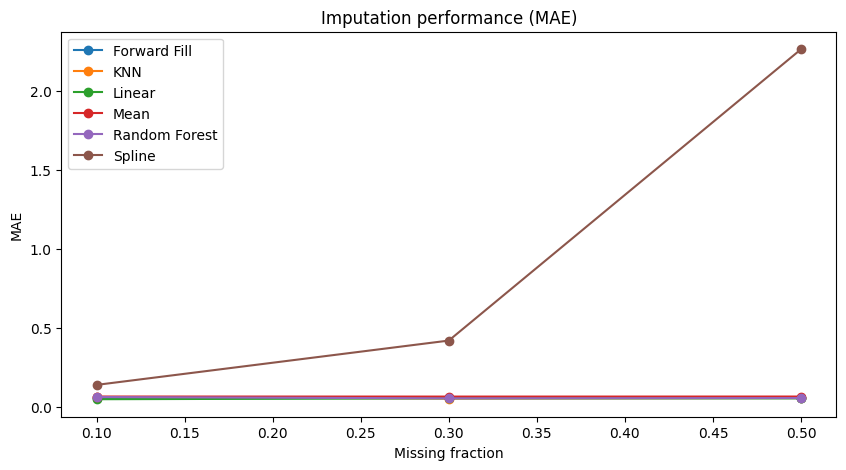

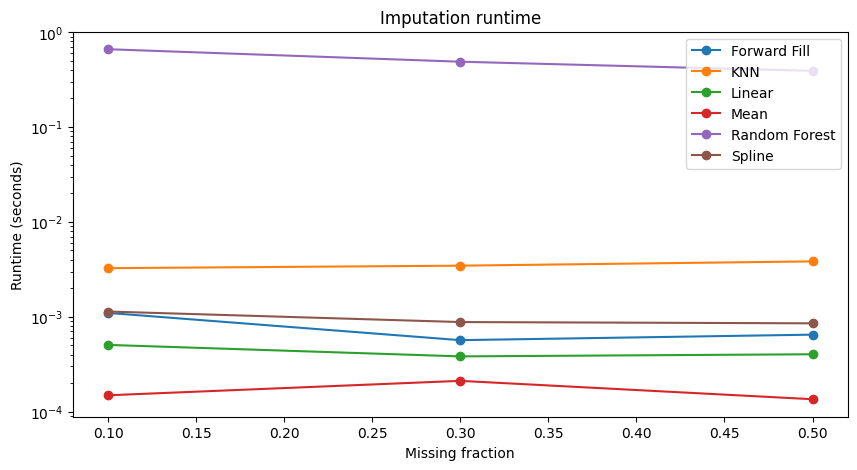

In [9]:
plt.figure(figsize=(10,5))

for method in summary.Method.unique():
    data=summary[summary.Method==method]
    plt.plot(
        data.Missingness,
        data.MAE,
        marker="o",
        label=method
    )

plt.xlabel("Missing fraction")
plt.ylabel("MAE")
plt.legend()
plt.title("Imputation performance (MAE)")
plt.show()

plt.figure(figsize=(10,5))

for method in summary.Method.unique():
    data=summary[summary.Method==method]
    plt.plot(
        data.Missingness,
        data.Runtime,
        marker="o",
        label=method
    )

plt.xlabel("Missing fraction")
plt.ylabel("Runtime (seconds)")
plt.legend()
plt.title("Imputation runtime")
plt.yscale('log') # Runtime can vary significantly, log scale is often helpful
plt.show()